In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/davidnagib/tweets-dataset/train.csv


In [28]:
%%time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

CPU times: user 74 µs, sys: 0 ns, total: 74 µs
Wall time: 80.1 µs


In [29]:
%%time
df = pd.read_csv("/kaggle/input/datasets/davidnagib/tweets-dataset/train.csv")
df.head()

CPU times: user 83.2 ms, sys: 20.1 ms, total: 103 ms
Wall time: 105 ms


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [39]:
%%time
texts = df['selected_text'].fillna("").astype(str)
labels = df['sentiment']

# Encode labels
le = LabelEncoder()
labels = le.fit_transform(labels)

# Tokenization
max_words = 20000
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

# Padding
max_len = 100
X = pad_sequences(sequences, maxlen=max_len)

y = labels

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

CPU times: user 780 ms, sys: 8.54 ms, total: 789 ms
Wall time: 793 ms


In [40]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

**RNN MODEL**

In [41]:
model_rnn = Sequential()
model_rnn.add(Embedding(max_words, 128))
model_rnn.add(SimpleRNN(64))
model_rnn.add(Dense(3, activation='softmax'))

model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_rnn = model_rnn.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

Epoch 1/3
275/275 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.6562 - loss: 0.7851 - val_accuracy: 0.8235 - val_loss: 0.4689
Epoch 2/3
275/275 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.8922 - loss: 0.3268 - val_accuracy: 0.8165 - val_loss: 0.4782
Epoch 3/3
275/275 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.9482 - loss: 0.1788 - val_accuracy: 0.7971 - val_loss: 0.5624


In [42]:
loss_rnn, acc_rnn = model_rnn.evaluate(X_test, y_test)
print("RNN Accuracy:", acc_rnn)

172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8048 - loss: 0.5671
RNN Accuracy: 0.8026196360588074


**LSTM MODEL**

In [43]:
model_lstm = Sequential()
model_lstm.add(Embedding(max_words, 128))
model_lstm.add(LSTM(64))
model_lstm.add(Dense(3, activation='softmax'))

model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_lstm = model_lstm.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

Epoch 1/3
275/275 ━━━━━━━━━━━━━━━━━━━━ 29s 98ms/step - accuracy: 0.6565 - loss: 0.7847 - val_accuracy: 0.8326 - val_loss: 0.4448
Epoch 2/3
275/275 ━━━━━━━━━━━━━━━━━━━━ 26s 96ms/step - accuracy: 0.8781 - loss: 0.3527 - val_accuracy: 0.8383 - val_loss: 0.4368
Epoch 3/3
275/275 ━━━━━━━━━━━━━━━━━━━━ 26s 93ms/step - accuracy: 0.9301 - loss: 0.2187 - val_accuracy: 0.8158 - val_loss: 0.4891


In [44]:
loss_lstm, acc_lstm = model_lstm.evaluate(X_test, y_test)
print("LSTM Accuracy:", acc_lstm)

172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8246 - loss: 0.4898
LSTM Accuracy: 0.8224486112594604


**Comparison B/W RNN and LSTM**

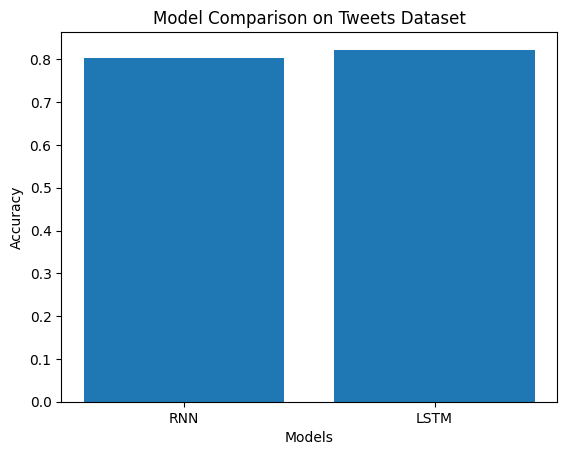

In [45]:
models = ['RNN', 'LSTM']
accuracies = [acc_rnn, acc_lstm]

plt.bar(models, accuracies)
plt.title("Model Comparison on Tweets Dataset")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

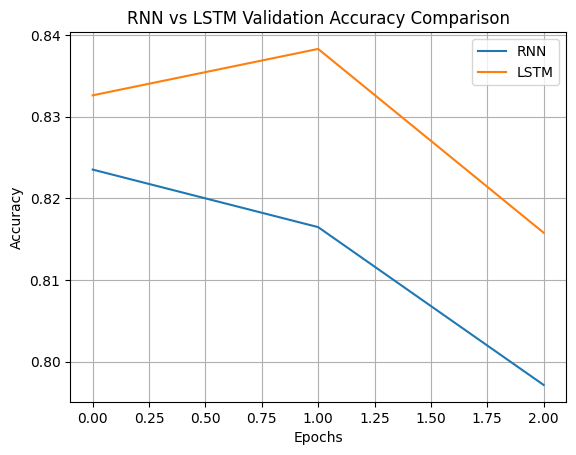

In [46]:
# RNN vs LSTM Accuracy Comparison (Epoch-wise)

plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')

plt.title("RNN vs LSTM Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()